In [5]:
# Read csv into pandas
import pandas as pd
import matplotlib.pyplot as plt
# Had to remove manually the first two lines since they where 2 elements long
df_untouched = pd.read_csv('API_GC.XPN.TOTL.GD.ZS_DS2_en_csv_v2_753336.csv')

In [6]:
# Make a copy of the untouched DataFrame
df = df_untouched.copy()

# Selection of countries
countries = ['Italy', 'Switzerland', 'France', 'Poland']
df = df[df['Country Name'].isin(countries)]
# Selection of years
years = [str(year) for year in range(2002, 2024)]
df = df[['Country Name'] + years]

print(df.head())

    Country Name       2002       2003       2004       2005       2006  \
37   Switzerland  19.481950  18.341599  18.170168  17.822231  16.891722   
77        France  46.148132  46.378152  45.712368  45.748648  45.247946   
116        Italy  39.343137  39.509542  38.712773  39.043793  39.604794   
190       Poland  39.585154  40.493717  37.824416  36.960695  36.662676   

          2007       2008       2009       2010  ...       2014       2015  \
37   16.354304  15.839785  16.918583  16.719745  ...  16.719264  17.067445   
77   44.911154  45.234107  48.405932  49.692529  ...  49.120785  48.449188   
116  39.074387  40.556207  44.037498  42.692992  ...  43.569825  43.529352   
190  35.089497  35.811546  36.725926  36.734575  ...  35.074902  34.138737   

          2016       2017       2018       2019       2020       2021  \
37   17.240823  17.216217  16.718224  16.853061  20.043195  18.966752   
77   48.150043  48.466342  47.100077  45.889790  51.963631  49.994444   
116  43.201402

In [7]:
# Save to a new CSV file
df.to_csv('Expense_of_GDP_percentage.csv', index=False)

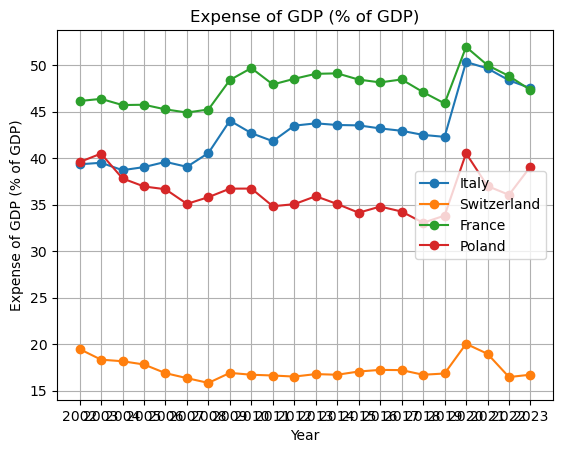

In [8]:
# Plot
for country in countries:
    plt.plot(years, df[df['Country Name'] == country].iloc[0, 1:], marker='o', label=country)
plt.title('Expense of GDP (% of GDP)')
plt.xlabel('Year')
plt.ylabel('Expense of GDP (% of GDP)')
plt.legend()
plt.grid()
plt.show()

In [9]:
#weighted average with increasing weights for more recent years
df_expenditure = df.copy()
import numpy as np

weights = np.arange(1, len(years) + 1)
print("Weights:", weights)
df_expenditure['Weighted Average'] = df_expenditure[years].apply(lambda row: np.average(row.dropna(), weights=weights[:len(row.dropna())]), axis=1)
print(df_expenditure[['Country Name', 'Weighted Average', '2022']])

Weights: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
    Country Name  Weighted Average       2022
37   Switzerland         17.244102  16.469270
77        France         48.233561  48.833867
116        Italy         44.550114  48.370264
190       Poland         36.040263  36.063241
